In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn import preprocessing
from sklearn.preprocessing import MultiLabelBinarizer
import seaborn as sns
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
df_admits = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\diagnoses_icd.csv.gz', compression='gzip')
df_transfers = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar.csv.gz', compression='gzip')

In [2]:
df_admits = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\diagnoses_icd.csv.gz', compression='gzip')
#df_transfers = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar.csv.gz', compression='gzip')

In [ ]:
#print(df_admits.head(10))
#print(df_diagnosis.head(10))
#print(df_icd_proc.head(10))
#print(df_icd_diagnosis.head(10))
df_pat.head(10)

In [ ]:
# Data Checks

#df_admits.isna().any() # check which columns have NaN
df_admits.loc[:,df_admits.isna().any()]
#df_admits[df_admits['admission_location'] == '']
#pd.reset_option('display.max_rows')


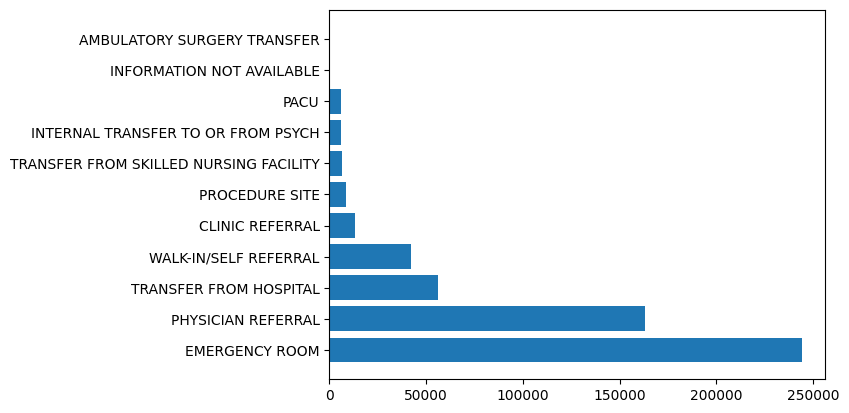

In [3]:
plt.barh(df_admits['admission_location'].value_counts().index,df_admits.admission_location.value_counts().values)
plt.show() # to check for missing values 

In [3]:
# Join diagnosis, admissions and procs
df_admit_icd = pd.merge(df_admits,df_diagnosis,how = 'left', on = 'hadm_id')
df_admit_diagnosis = pd.merge(df_admit_icd,df_icd_diagnosis,how = 'left', on = 'icd_code')
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_icd_proc,how = 'left', on = 'icd_code')
df_admit_diagnosis.drop(columns= ['subject_id_y'], inplace = True)
df_admit_diagnosis.rename(columns={'long_title_x': 'icd_diagnosis_name','long_title_y':'proc_name','subject_id_x':'subject_id'}, inplace=True)
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_pat[['subject_id', 'anchor_age','gender']],how = 'left', on = 'subject_id')

In [4]:
# Replace all NaN with 'No Diagnosis'
df_admit_diagnosis['icd_diagnosis_name'] = df_admit_diagnosis['icd_diagnosis_name'].fillna('No Diagnosis')
df_admit_diagnosis['proc_name'] = df_admit_diagnosis['proc_name'].fillna('No Procedure')
df_admit_diagnosis['icd_code'] = df_admit_diagnosis['icd_code'].fillna('No ICD Code')
df_admit_diagnosis[df_admit_diagnosis['proc_name'].isna()]

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,hospital_expire_flag,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender


In [5]:
icd_counts = df_admit_diagnosis.icd_code.value_counts()

# Get the top 100 ICD codes by frequency
top_100_icd = df_admit_diagnosis['icd_code'].value_counts().nlargest(201).index

# Map ICD codes — keep top 100, replace others with 'Other Code'
df_admit_diagnosis['icd_code_converted'] = df_admit_diagnosis['icd_code'].apply(
    lambda x: str(x) if x in top_100_icd else 'Other Code'
)

df_admit_diagnosis.drop(columns = ['icd_version_y','icd_version_x','edregtime','edouttime','deathtime','admit_provider_id','hospital_expire_flag',
                                          'seq_num','icd_code','language','icd_version'],inplace = True)

In [6]:
pd.set_option('display.max_rows', 10000)    
print(df_admit_diagnosis.icd_code_converted.value_counts().head(10000))

icd_code_converted
Other Code    3492294
4019           102368
E785            84570
I10             83775
2724            67293
Z87891          62806
K219            56157
53081           48628
25000           43077
F329            41876
I2510           41550
F419            38911
42731           37070
4280            36606
311             36349
41401           36083
N179            35884
Z20822          33113
V1582           31705
Z7901           30957
5849            29136
2449            28521
E039            28000
Z794            27642
E119            26266
3051            25879
2859            24395
F17210          24106
G4733           23933
40390           23831
V5861           22635
30000           22399
E669            22004
V270            21238
D649            21137
I4891           21022
J45909          20679
5990            20387
Z7902           19961
2720            19880
Y929            19830
49390           19703
V5867           19600
D62             19356
Z66          

In [7]:
df_admit_diagnosis.head()

,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,marital_status,race,icd_diagnosis_name,proc_name,anchor_age,gender,icd_code_converted
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,Portal hypertension,No Procedure,52,F,Other Code
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,Other ascites,No Procedure,52,F,Other Code
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,Cirrhosis of liver without mention of alcohol,No Procedure,52,F,5715
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,Unspecified viral hepatitis C without hepatic ...,No Procedure,52,F,Other Code
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,"Chronic airway obstruction, not elsewhere clas...",Excision of anus,52,F,496


In [8]:
# Group first to reduce data size
df_admit_diagnosis_grouped = df_admit_diagnosis.groupby(['hadm_id', 'subject_id']).agg({  
     'admission_type':'first',
     'admission_location': 'first',
     'discharge_location':'first',
     'admittime':'first',
     'dischtime':'first',
     'insurance':'first',
     'marital_status': 'first',
     'race':'first',
     'anchor_age': 'first',
     'gender':'first',
     'icd_code_converted': lambda x: set(x),
     'icd_diagnosis_name': lambda x: set(x),
     'proc_name': lambda x: set(x),
     }).reset_index()
df_admit_diagnosis_grouped.head(5)  

,hadm_id,subject_id,admission_type,admission_location,discharge_location,admittime,dischtime,insurance,marital_status,race,anchor_age,gender,icd_code_converted,icd_diagnosis_name,proc_name
0,20000019,10467237,EW EMER.,EMERGENCY ROOM,HOME,2159-03-20 21:08:00,2159-03-23 16:54:00,Medicaid,SINGLE,HISPANIC/LATINO - GUATEMALAN,76,F,"{2859, 4019, 49390, 2724, Other Code, 2761, 25...","{Unspecified septicemia, Other and unspecified...","{Suture of laceration of palate, Biopsy of mou..."
1,20000024,16925328,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,2151-05-25 21:44:00,2151-05-26 18:36:00,Medicare,SINGLE,WHITE,84,F,"{Z9181, M810, Other Code, I10}","{History of falling, Ataxia, unspecified, Lega...",{No Procedure}
2,20000034,19430048,DIRECT OBSERVATION,PHYSICIAN REFERRAL,None,2174-05-22 19:13:00,2174-05-24 17:27:00,Medicare,SINGLE,BLACK/CARIBBEAN ISLAND,72,M,"{N183, E43, E1122, Z8673, Z794, N400, R339, E8...","{Emphysema, unspecified, Chronic kidney diseas...","{No Procedure, Physical Rehabilitation and Dia..."
3,20000041,18910522,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,2143-09-03 07:15:00,2143-09-06 13:50:00,Private,SINGLE,WHITE,62,F,"{V1251, 4019, 2724, 27800, Other Code, 53081}","{Other and unspecified hyperlipidemia, Persona...","{No Procedure, Other diagnostic procedures on ..."
4,20000045,13413708,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,2138-05-21 16:25:00,2138-05-29 02:05:00,Private,DIVORCED,WHITE,51,F,"{A419, N390, E8339, Other Code, Z87891}","{Personal history of COVID-19, Urinary tract i...",{No Procedure}


In [9]:
# Assign admission ranks throughout time
# Readmission is within 30 days of discharge and next admission so insert flag

df_admit_diagnosis_grouped['admittime'] = pd.to_datetime(df_admit_diagnosis_grouped['admittime'])
df_admit_diagnosis_grouped['dischtime'] = pd.to_datetime(df_admit_diagnosis_grouped['dischtime'])

df_admit_diagnosis_grouped['admission_rank'] = df_admit_diagnosis_grouped.groupby('subject_id')['admittime'].rank(method='dense', ascending=True)
df_admit_diagnosis_grouped.sort_values(by = ['admission_rank'],ascending= True, inplace= True)
# Get next admission's out time for each patient
df_admit_diagnosis_grouped['last_dischtime'] = df_admit_diagnosis_grouped.groupby('subject_id')['dischtime'].shift(1)

# Calculate days until next visit
df_admit_diagnosis_grouped['days_from_last'] = (df_admit_diagnosis_grouped['admittime'] - df_admit_diagnosis_grouped['last_dischtime']).dt.days

# Create readmission flag (1 if last visit is within 30 days, else 0)
df_admit_diagnosis_grouped['readmission'] = df_admit_diagnosis_grouped['days_from_last'].apply(lambda x: 1 if pd.notnull(x) and x <= 30 and x >= 0 else 0)

#df_admit_diagnosis_grouped[df_admit_diagnosis_grouped['subject_id'] == 10000032]

In [10]:
# label encode the text columns
df_admit_diagnosis_encoded = df_admit_diagnosis_grouped.drop(columns= ['admittime','dischtime','last_dischtime','days_from_last', 
                                                                       'admission_rank','icd_diagnosis_name','proc_name']) # drop irrelevant cols

cols_to_encode = ['admission_type','admission_location','discharge_location','insurance','race','gender','marital_status']
label_encoder = preprocessing.LabelEncoder()
for col in cols_to_encode:
    df_admit_diagnosis_encoded[col] = label_encoder.fit_transform(df_admit_diagnosis_encoded[col])
df_admit_diagnosis_encoded[df_admit_diagnosis_encoded['subject_id'] == 10000032]


,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,icd_code_converted,readmission
141961,22595853,10000032,8,8,6,0,3,28,52,0,"{V1582, 5715, Other Code, 29680, 496}",0
155119,22841357,10000032,5,2,6,0,3,28,52,0,"{3051, 5715, Other Code, 2761, 2875, 496}",0
495453,29079034,10000032,5,2,6,0,3,28,52,0,"{2767, 3051, V462, 5715, Other Code, 2761, 296...",1
313493,25742920,10000032,5,2,8,0,3,28,52,0,"{2767, 3051, V462, 5715, Other Code, 2761, 787...",1


In [11]:
mlb = MultiLabelBinarizer(sparse_output=True)
X = mlb.fit_transform(df_admit_diagnosis_encoded['icd_code_converted'])

df_icd_encoded = pd.DataFrame.sparse.from_spmatrix(
    X,
    index=df_admit_diagnosis_encoded['hadm_id'],
    columns=mlb.classes_
)

In [12]:
df_admit_diagnosis_icd_encoded = pd.merge(
    df_admit_diagnosis_encoded,
    df_icd_encoded,
    on='hadm_id'
)
df_admit_diagnosis_icd_encoded.drop(columns=['Other Code','icd_code_converted'], inplace=True)

In [13]:
pd.set_option('display.max_columns', None)
df_admit_diagnosis_icd_encoded.head()

,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,readmission,2449,25000,25060,2720,2724,2749,2761,2762,27651,2767,2768,27800,27801,2809,2851,28521,2859,2875,28860,29680,30000,3004,30500,3051,311,32723,33829,34590,34690,3572,4019,40390,40391,412,41400,41401,4168,4240,4241,42731,42789,4280,42822,42832,4439,486,49390,496,51881,53081,56400,5715,5849,5853,5856,5859,5990,60000,71590,73300,78650,78659,78701,78791,78820,A419,D509,D62,D631,D649,D6959,D696,D72829,E039,E1122,E1140,E1165,E119,E43,E559,E6601,E669,E7800,E785,E8339,E8342,E8490,E8497,E860,E861,E870,E871,E872,E875,E876,E8788,E8798,E8809,E8889,F0390,F05,F17210,F319,F329,F419,F4310,G40909,G43909,G4700,G4733,G8929,G92,H409,I10,I110,I129,I130,I2510,I252,I2720,I480,I4891,I5022,I5023,I5032,I5033,I959,J189,J449,J45909,J9601,K219,K5900,M109,M1990,M810,N179,N183,N186,N189,N390,N400,R000,R079,R0902,R1310,R197,R339,R45851,T451X5A,V103,V1046,V1251,V1254,V153,V1581,V1582,V173,V270,V433,V4364,V4365,V4501,V4581,V4582,V462,V4986,V5861,V5866,V5867,V600,V6284,V667,V707,Y838,Y92009,Y92230,Y92239,Y929,Z20822,Z20828,Z23,Z370,Z515,Z66,Z781,Z7901,Z7902,Z794,Z8249,Z853,Z8546,Z85828,Z86711,Z86718,Z8673,Z87891,Z9181,Z951,Z955,Z992
0,20001596,15327072,4,10,13,3,1,7,65,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,20001633,18030855,5,2,6,0,2,28,28,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,20001747,12270767,6,8,7,1,1,28,91,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,20001770,10117812,5,10,11,0,2,28,35,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,20001800,11828074,4,2,13,4,1,28,59,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [14]:
print("Length of Original Data: ",len(df_admit_diagnosis_encoded))
print("Length of Data After MLB: ",len(df_admit_diagnosis_icd_encoded))

Length of Original Data:  546028
Length of Data After MLB:  546028


Medication Data

In [15]:
df_medi.drop(columns = ['enter_provider_id','charttime','scheduletime','storetime','emar_id','emar_seq','poe_id','pharmacy_id','enter_provider_id'
                        ,'charttime','scheduletime','storetime'], inplace= True)
df_medi['medication'] = df_medi['medication'].fillna('No Medication')
df_medi.head(5)

,subject_id,hadm_id,medication,event_txt
0,10000032,22595853.0,Heparin,Administered
1,10000032,22595853.0,Raltegravir,Administered
2,10000032,22595853.0,Sodium Chloride 0.9% Flush,Flushed
3,10000032,22595853.0,Nicotine Patch,Not Applied
4,10000032,22595853.0,Furosemide,Not Given


In [16]:
# Define grouping rules for usage
administered = [
    'Administered', 'Partial Administered', 'Applied',
    'Confirmed', 'Started', 'Administered in Other Location',
    'Started in Other Location', 'Administered Bolus from IV Drip',
    'Applied in Other Location', 'Removed Existing / Applied New',
    'Removed Existing / Applied New in Other Location',
    'Restarted', 'Restarted in Other Location'
]

not_administered = [
    'Not Applied', 'Not Given', 'Not Flushed', 'Hold Dose', 'Removed',
    'Not Confirmed', 'Not Started', 'Not Assessed', 'Not Removed',
    'Not Stopped', 'Not Read', 'Not Given per Sliding Scale',
    'Not Stopped per Sliding Scale', 'Not Started per Sliding Scale',
    'Not Given per Sliding Scale in Other Location', 'Read', 'Read in Other Location', 'Stopped', 'Stopped As Directed',
    'Stopped - Unscheduled', 'Stopped - Unscheduled in Other Location',
    'Rate Change', 'Rate Change in Other Location','Removed in Other Location',
    'Confirmed in Other Location'

]

delayed = [s for s in df_medi['event_txt'].dropna().unique() if s.startswith('Delayed')]

other = [
    'Flushed', 'Flushed in Other Location', 'Assessed',
    'Assessed in Other Location', 'Infusion Reconciliation',
    'Infusion Reconciliation Not Done', 'Pain score re-assessment',
    'Pain score re-assess not done', 'Documented in O.R. Holding',
    'TPN Rate Not Changed', ' in Other Location', 'Partial ',
]

In [17]:
# Make sure event lists are sets for faster lookup
administered_set = set(administered)
not_administered_set = set(not_administered)
delayed_set = set(delayed)

# Initialize with 'Other'
df_medi['usage'] = 'Other'

# Apply conditions using boolean indexing
mask_admin = df_medi['event_txt'].isin(administered_set) & (df_medi['medication'] != 'No Medication')
mask_not_admin = df_medi['event_txt'].isin(not_administered_set)
mask_delayed = df_medi['event_txt'].isin(delayed_set)

df_medi.loc[mask_admin, 'usage'] = 'Administered'
df_medi.loc[mask_not_admin, 'usage'] = 'Not Administered'
df_medi.loc[mask_delayed, 'usage'] = 'Delayed'

# Filter to only include 'Administered'
df_medi = df_medi[df_medi['usage'] == 'Administered']
df_medi['medication'] = df_medi['medication'].str.lower()

In [18]:
df_medi[df_medi['usage']=='Administered']

,subject_id,hadm_id,medication,event_txt,usage
0,10000032,22595853.0,heparin,Administered,Administered
1,10000032,22595853.0,raltegravir,Administered,Administered
7,10000032,22595853.0,albuterol inhaler,Administered,Administered
8,10000032,22595853.0,furosemide,Administered,Administered
9,10000032,22595853.0,spironolactone,Administered,Administered
...,...,...,...,...,...
42808584,19999828,29734428.0,lorazepam,Administered,Administered
42808585,19999828,29734428.0,insulin,Administered,Administered
42808588,19999828,NaN,morphine sulfate,Administered,Administered
42808590,19999828,NaN,ondansetron,Administered,Administered


In [19]:
# Step 1: Get the top 100 medications by frequency
top_100_meds = df_medi['medication'].value_counts().nlargest(201).index

# Step 2: Replace all non-top-100 medications with 'Other'
df_medi['medication_grouped'] = df_medi['medication'].apply(
    lambda x: str(x) if x in top_100_meds else 'Other Medication'
)

In [20]:
# Group first to reduce data size
df_medi.drop(columns=['medication','event_txt','usage'],inplace=True)

df_medi_grouped = df_medi.groupby(['hadm_id', 'subject_id']).agg({  
     'medication_grouped': lambda x: set(x),
     }).reset_index()
df_medi_grouped.head(5)  

,hadm_id,subject_id,medication_grouped
0,20000024.0,16925328,"{folic acid, thiamine, acetaminophen, heparin,..."
1,20000034.0,19430048,"{amlodipine, mirtazapine, folic acid, senna, t..."
2,20000045.0,13413708,"{hydromorphone (dilaudid), magnesium sulfate, ..."
3,20000147.0,14990224,"{ketorolac, senna, propofol, mupirocin ointmen..."
4,20000180.0,15296741,"{senna, ceftriaxone, bisacodyl, lisinopril, do..."


In [21]:
mlb = MultiLabelBinarizer(sparse_output=True)
X = mlb.fit_transform(df_medi_grouped['medication_grouped'])

df_medi_encoded = pd.DataFrame.sparse.from_spmatrix(
    X,
    index=df_medi_grouped['hadm_id'],
    columns=mlb.classes_
)

In [22]:
df_medi_encoded.drop(columns=['Other Medication'], inplace=True)

In [23]:
df_medi_encoded.head()

,acetaminophen,acetaminophen (liquid),acetaminophen iv,acetylcysteine 20%,acyclovir,albuterol 0.083% neb soln,albuterol inhaler,allopurinol,alprazolam,aluminum-magnesium hydrox.-simethicone,amiodarone,amlodipine,amoxicillin-clavulanic acid,ampicillin,ampicillin-sulbactam,apixaban,artificial tears,artificial tears gel 1%,ascorbic acid,aspirin,aspirin ec,atenolol,atorvastatin,atovaquone suspension,azithromycin,baclofen,benzonatate,bisacodyl,brimonidine tartrate 0.15% ophth.,bupropion (sustained release),buspirone,calcitriol,calcium carbonate,calcium gluconate,caphosol,captopril,carbidopa-levodopa (25-100),carvedilol,cefazolin,cefepime,ceftazidime,ceftriaxone,cephalexin,cetirizine,chlorhexidine gluconate 0.12% oral rinse,ciprofloxacin,ciprofloxacin hcl,citalopram,clindamycin,clonazepam,clonidine,clopidogrel,creon 12,cyanocobalamin,cyclobenzaprine,dexamethasone,dexmedetomidine,dextrose 50%,diazepam,diltiazem,diphenhydramine,docusate sodium,dorzolamide 2%/timolol 0.5% ophth.,doxycycline hyclate,duloxetine,duloxetine dr,enoxaparin (prophylaxis),enoxaparin sodium,erythromycin 0.5% ophth oint,escitalopram oxalate,famotidine,fentanyl citrate,ferrous sulfate,finasteride,fluconazole,fluoxetine,fluticasone propionate 110mcg,fluticasone propionate nasal,fluticasone-salmeterol diskus (250/50),fluticasone-salmeterol diskus (500/50),folic acid,furosemide,gabapentin,guaifenesin,guaifenesin er,haloperidol,heparin,heparin dwell (1000 units/ml),hydralazine,hydrochlorothiazide,hydrocortisone na succ.,hydromorphone (dilaudid),hydroxyzine,ibuprofen,insulin,ipratropium bromide mdi,ipratropium bromide neb,ipratropium-albuterol neb,isosorbide dinitrate,isosorbide mononitrate (extended release),ketorolac,labetalol,lacosamide,lactulose,lamotrigine,lansoprazole oral disintegrating tab,latanoprost 0.005% ophth. soln.,levetiracetam,levofloxacin,levothyroxine sodium,lidocaine 5% patch,lisinopril,loperamide,loratadine,lorazepam,losartan potassium,magnesium oxide,magnesium sulfate,magnesium sulfate replacement (critical care and oncology),meropenem,metformin (glucophage),methadone,methylprednisolone sodium succ,metoclopramide,metoprolol succinate xl,metoprolol tartrate,metronidazole,metronidazole (flagyl),miconazole powder 2%,midazolam,midodrine,mirtazapine,montelukast,morphine sr (ms contin),morphine sulfate,multivitamins,multivitamins w/minerals,mupirocin ointment 2%,mycophenolate mofetil,nafcillin,nephrocaps,neutra-phos,nicotine patch,nimodipine,nitroglycerin,norepinephrine,nystatin oral suspension,octreotide acetate,olanzapine,omeprazole,ondansetron,oxybutynin,oxycodone (immediate release),oxycodone (immediate release),oxycodone liquid,oxycodone sr (oxycontin),pantoprazole,phenylephrine,phosphorus,piperacillin-tazobactam,polyethylene glycol,potassium chloride,pravastatin,prednisolone acetate 1% ophth. susp.,prednisone,pregabalin,prochlorperazine,propofol,quetiapine fumarate,ramelteon,ranitidine,rifaximin,risperidone,rosuvastatin calcium,senna,sertraline,sevelamer carbonate,simethicone,simvastatin,sodium bicarbonate,sodium chloride,spironolactone,sucralfate,sulfameth/trimethoprim ds,sulfameth/trimethoprim ss,tacrolimus,tamsulosin,thiamine,tiotropium bromide,topiramate (topamax),torsemide,tramadol,trazodone,ursodiol,vancomycin,vancomycin oral liquid,vasopressin,venlafaxine xr,vitamin d,vitamin d3 (cholecalciferol),warfarin
hadm_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
20000024.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
20000034.0,1,0,0,0,0,0,0,

In [24]:
df_full_dataset = pd.merge(
    df_admit_diagnosis_icd_encoded,
    df_medi_encoded,
    how='left',
    on='hadm_id'
)
df_full_dataset.fillna(0, inplace=True)

In [25]:
df_full_dataset

,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,readmission,2449,25000,25060,2720,2724,2749,2761,2762,27651,2767,2768,27800,27801,2809,2851,28521,2859,2875,28860,29680,30000,3004,30500,3051,311,32723,33829,34590,34690,3572,4019,40390,40391,412,41400,41401,4168,4240,4241,42731,42789,4280,42822,42832,4439,486,49390,496,51881,53081,56400,5715,5849,5853,5856,5859,5990,60000,71590,73300,78650,78659,78701,78791,78820,A419,D509,D62,D631,D649,D6959,D696,D72829,E039,E1122,E1140,E1165,E119,E43,E559,E6601,E669,E7800,E785,E8339,E8342,E8490,E8497,E860,E861,E870,E871,E872,E875,E876,E8788,E8798,E8809,E8889,F0390,F05,F17210,F319,F329,F419,F4310,G40909,G43909,G4700,G4733,G8929,G92,H409,I10,I110,I129,I130,I2510,I252,I2720,I480,I4891,I5022,I5023,I5032,I5033,I959,J189,J449,J45909,J9601,K219,K5900,M109,M1990,M810,N179,N183,N186,N189,N390,N400,R000,R079,R0902,R1310,R197,R339,R45851,T451X5A,V103,V1046,V1251,V1254,V153,V1581,V1582,V173,V270,V433,V4364,V4365,V4501,V4581,V4582,V462,V4986,V5861,V5866,V5867,V600,V6284,V667,V707,Y838,Y92009,Y92230,Y92239,Y929,Z20822,Z20828,Z23,Z370,Z515,Z66,Z781,Z7901,Z7902,Z794,Z8249,Z853,Z8546,Z85828,Z86711,Z86718,Z8673,Z87891,Z9181,Z951,Z955,Z992,acetaminophen,acetaminophen (liquid),acetaminophen iv,acetylcysteine 20%,acyclovir,albuterol 0.083% neb soln,albuterol inhaler,allopurinol,alprazolam,aluminum-magnesium hydrox.-simethicone,amiodarone,amlodipine,amoxicillin-clavulanic acid,ampicillin,ampicillin-sulbactam,apixaban,artificial tears,artificial tears gel 1%,ascorbic acid,aspirin,aspirin ec,atenolol,atorvastatin,atovaquone suspension,azithromycin,baclofen,benzonatate,bisacodyl,brimonidine tartrate 0.15% ophth.,bupropion (sustained release),buspirone,calcitriol,calcium carbonate,calcium gluconate,caphosol,captopril,carbidopa-levodopa (25-100),carvedilol,cefazolin,cefepime,ceftazidime,ceftriaxone,cephalexin,cetirizine,chlorhexidine gluconate 0.12% oral rinse,ciprofloxacin,ciprofloxacin hcl,citalopram,clindamycin,clonazepam,clonidine,clopidogrel,creon 12,cyanocobalamin,cyclobenzaprine,dexamethasone,dexmedetomidine,dextrose 50%,diazepam,diltiazem,diphenhydramine,docusate sodium,dorzolamide 2%/timolol 0.5% ophth.,doxycycline hyclate,duloxetine,duloxetine dr,enoxaparin (prophylaxis),enoxaparin sodium,erythromycin 0.5% ophth oint,escitalopram oxalate,famotidine,fentanyl citrate,ferrous sulfate,finasteride,fluconazole,fluoxetine,fluticasone propionate 110mcg,fluticasone propionate nasal,fluticasone-salmeterol diskus (250/50),fluticasone-salmeterol diskus (500/50),folic acid,furosemide,gabapentin,guaifenesin,guaifenesin er,haloperidol,heparin,heparin dwell (1000 units/ml),hydralazine,hydrochlorothiazide,hydrocortisone na succ.,hydromorphone (dilaudid),hydroxyzine,ibuprofen,insulin,ipratropium bromide mdi,ipratropium bromide neb,ipratropium-albuterol neb,isosorbide dinitrate,isosorbide mononitrate (extended release),ketorolac,labetalol,lacosamide,lactulose,lamotrigine,lansoprazole oral disintegrating tab,latanoprost 0.005% ophth. soln.,levetiracetam,levofloxacin,levothyroxine sodium,lidocaine 5% patch,lisinopril,loperamide,loratadine,lorazepam,losartan potassium,magnesium oxide,magnesium sulfate,magnesium sulfate replacement (critical care and oncology),meropenem,metformin (glucophage),methadone,methylprednisolone sodium succ,metoclopramide,metoprolol succinate xl,metoprolol tartrate,metronidazole,metronidazole (flagyl),miconazole powder 2%,midazolam,midodrine,mirtazapine,montelukast,morphine sr (ms contin),morphine sulfate,multivitamins,multivitamins w/minerals,mupirocin ointment 2%,mycophenolate mofetil,nafcillin,nephrocaps,neutra-phos,nicotine patch,nimodipine,nitroglycerin,norepinephrine,nystatin oral suspension,octreotide acetate,olanzapine,omeprazole,ondansetron,oxybutynin,oxycodone (immediate release),oxycodone (immediate release),oxycodone liquid,oxycodone sr (oxycontin),pantoprazole,phenylephrine,phosphorus,piperacillin-tazobactam,polyethylene g

In [ ]:
# Correlation matrix
corr_matrix = df_full_dataset.corr()

plt.figure(figsize=(15, 15))

sns.heatmap(
    corr_matrix,
    annot=False,  # Turn off annotation values
    cmap='coolwarm',
    xticklabels=corr_matrix.columns,
    yticklabels=corr_matrix.columns
)

plt.title("Correlation Matrix")

# Make axis label text small
plt.xticks(rotation=45, fontsize=6)
plt.yticks(rotation=0, fontsize=6)

plt.tight_layout()
plt.show()


In [ ]:
# Get correlations with the target variable
target_corr = df_full_dataset.corr()['readmission'].drop('readmission')

# Filter for absolute correlations above 0.2
important_features = target_corr[abs(target_corr) > 0.02]

# Optional: Sort them by strength
important_features = important_features.sort_values(ascending=False)

print(important_features)


In [26]:
X = df_full_dataset.drop('readmission', axis=1)
y = df_full_dataset.readmission

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [28]:
logreg = LogisticRegression(penalty= 'l1',solver='liblinear',  random_state=42, max_iter=1000)

# fit the model with data
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

C:\Users\Saaqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
C:\Users\Saaqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [29]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[107170,   1606],
       [ 25782,   1949]])

Text(0.5, 427.9555555555555, 'Predicted label')

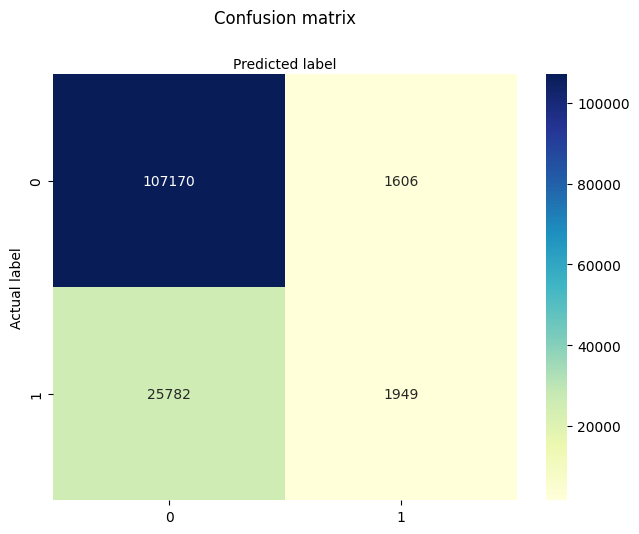

In [30]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


In [31]:
from sklearn.metrics import classification_report
target_names = ['not readmission', 'readmission']
print(classification_report(y_test, y_pred, target_names=target_names))

                 precision    recall  f1-score   support

not readmission       0.81      0.99      0.89    108776
    readmission       0.55      0.07      0.12     27731

       accuracy                           0.80    136507
      macro avg       0.68      0.53      0.51    136507
   weighted avg       0.75      0.80      0.73    136507



C:\Users\Saaqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


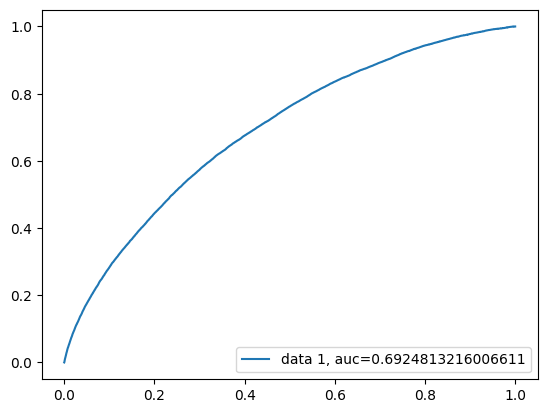

In [32]:
y_pred_proba = logreg.predict_proba(X_test)[::,1] # gets confidence level for each prediction
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

In [ ]:
coef = logreg.coef_[0]  # For binary classification
feature_names = X_train.columns  

In [ ]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef,
    'Abs_Coefficient': np.abs(coef)
})

# Sort by absolute impact
coef_df_abs = coef_df.sort_values(by='Abs_Coefficient', ascending=False)
print(coef_df_abs.head(10))

        Feature  Coefficient  Abs_Coefficient
192        Z370    -1.329136         1.329136
354  nimodipine    -1.256045         1.256045
168        V270    -1.172969         1.172969
181       V6284     0.747834         0.747834
107       E8809    -0.706749         0.706749
184        Y838     0.686093         0.686093
180        V600     0.685856         0.685856
245    caphosol    -0.683731         0.683731
158      R45851     0.624948         0.624948
105       E8788     0.617914         0.617914


In [38]:
coef_df_pstve = coef_df.sort_values(by='Coefficient', ascending=False)
print(coef_df_pstve.head(10))

                    Feature  Coefficient  Abs_Coefficient
181                   V6284     0.747834         0.747834
184                    Y838     0.686093         0.686093
180                    V600     0.685856         0.685856
158                  R45851     0.624948         0.624948
105                   E8788     0.617914         0.617914
406  vancomycin oral liquid     0.602396         0.602396
382               rifaximin     0.600380         0.600380
64                     5856     0.512371         0.512371
383             risperidone     0.497223         0.497223
234   atovaquone suspension     0.471400         0.471400


In [ ]:
# test 